# Construção da base analítica — Reclamações NIP / ANS

**TCC · MBA em Data Science e Analytics · USP/Esalq**

Este notebook cobre a **Etapa 1** do trabalho: a partir dos microdados públicos da
Agência Nacional de Saúde Suplementar (ANS), produzir uma base tratada e documentada
para os modelos de classificação da Etapa 2.

---

## Objetivo

Modelar a probabilidade de uma demanda de Notificação de Intermediação Preliminar (NIP)
**não ser resolvida**, a partir de características do beneficiário, do plano, da operadora
e do motivo da reclamação.

## Fontes de dados

| Base | Conteúdo | Granularidade |
|---|---|---|
| **NIP** | Demandas dos consumidores (tabela fato) | uma linha por demanda |
| **IGR** | Índice Geral de Reclamações | operadora × competência × cobertura |
| **CADOP** | Cadastro de Operadoras Ativas | uma linha por operadora |

Todas obtidas no portal de dados abertos da ANS (`dados.gov.br` / `gov.br/ans`).
Período coberto pelas demandas: **2021 a 2026**.

> Os arquivos de dados **não** estão versionados neste repositório (ver `.gitignore`).
> Para reproduzir, baixe-os das fontes originais e ajuste os caminhos na seção 1.

## Estrutura deste notebook

| Seção | Conteúdo |
|---|---|
| 1 | Configuração e caminhos |
| 2 | Leitura das três bases |
| 3 | Padronização de tipos e chaves |
| 4 | Enriquecimento da base fato |
| 5 | Recorte amostral do estudo |
| 6 | Variáveis derivadas |
| 7 | Variável resposta |
| 8 | Exclusão por vazamento de informação |
| 9 | Tratamento de ausentes e valores implausíveis |
| 10 | Análise descritiva |
| 11 | Base final |
| A | Apêndice — coordenadas municipais (Power BI) |

---
## 1. Configuração

Caminhos centralizados nesta célula: para rodar em outro ambiente, basta alterar `RAIZ`.

In [ ]:
import os
import unicodedata
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
RAIZ = '/content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC'

PASTA_NIPS  = f'{RAIZ}/NIPS'
ARQUIVO_IGR = f'{RAIZ}/BENEF. IGR/IGR.csv'
ARQ_CADOP   = f'{RAIZ}/CADOP/CADOP.csv'

SAIDA = f'{RAIZ}/base_analitica_tcc.csv'

### Registro do funil amostral

Cada etapa que remove linhas é registrada aqui. A tabela resultante, exibida na seção 11,
documenta o caminho da base bruta até a amostra final

In [ ]:
FUNIL = []

def registrar(etapa, df, obs=''):
    anterior = FUNIL[-1]['linhas'] if FUNIL else None
    delta = '' if anterior is None else f'{len(df) - anterior:+,}'.replace(',', '.')
    FUNIL.append({'etapa': etapa, 'linhas': len(df), 'variação': delta, 'observação': obs})
    print(f"{etapa:<46} {len(df):>11,}  {delta:>12}".replace(',', '.'))

---
## 2. Leitura das três bases

Os arquivos anuais de NIP são lidos e concatenados. As bases auxiliares (IGR e CADOP)
são lidas separadamente e só entram na base fato na seção 4.

In [ ]:
# Caminho da pasta
pasta = "/content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/NIPS"

# Lista todos os arquivos CSV da pasta
arquivos_csv = glob(os.path.join(pasta, "*.csv"))

# Lê todos os CSVs e armazena em uma lista
lista_dfs = []

for arquivo in arquivos_csv:
    try:
        df = pd.read_csv(arquivo, sep =';', on_bad_lines="skip", encoding='utf-8', engine="python")
        lista_dfs.append(df)
        print(f"Arquivo carregado: {arquivo}")
    except Exception as e:
        print(f"Erro ao ler {arquivo}: {e}")

# Une todos os DataFrames
base = pd.concat(lista_dfs, ignore_index=True)

Arquivo carregado: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/NIPS/pda-013-demandas_dos_consumidores_nip-2021.csv
Arquivo carregado: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/NIPS/pda-013-demandas_dos_consumidores_nip-2022.csv
Arquivo carregado: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/NIPS/pda-013-demandas_dos_consumidores_nip-2026.csv
Arquivo carregado: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/NIPS/pda-013-demandas_dos_consumidores_nip-2025.csv
Arquivo carregado: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/NIPS/pda-013-demandas_dos_consumidores_nip-2023.csv
Arquivo carregado: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/NIPS/pda-013-demandas_dos_consumidores_nip-2024.csv


In [ ]:
registrar('Base NIP bruta (2021–2026)', base)

Base NIP bruta (2021–2026)                       1.595.006              


In [ ]:
igr = pd.read_csv('/content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/BENEF. IGR/IGR.csv', sep=';')
cadop = pd.read_csv('/content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/CADOP/CADOP.csv', sep=';')

/tmp/ipykernel_2182/2384261000.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  igr = pd.read_csv('/content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/BENEF. IGR/IGR.csv', sep=';')


In [ ]:
print('NIP  ', base.shape)
print('IGR  ', igr.shape)
print('CADOP', cadop.shape)

NIP   (1595006, 27)
IGR   (150501, 10)
CADOP (1110, 20)


In [ ]:
base.info()
print('_____________________________________________________________')
igr.info()
print('_____________________________________________________________')
cadop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1595006 entries, 0 to 1595005
Data columns (total 27 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   NUMERO_DA_DEMANDA           1595006 non-null  int64  
 1   ABERTURA_DA_DEMANDA         1595006 non-null  object 
 2   ANO_DE_REFERENCIA           1595006 non-null  int64  
 3   MES_DE_REFERENCIA           1595006 non-null  int64  
 4   SITUACAO_DA_DEMANDA         1595006 non-null  object 
 5   FORMA_DE_CONTATO_COM_A_ANS  1595006 non-null  object 
 6   ASSUNTO                     1595006 non-null  object 
 7   REGISTRO_OPERADORA          1594798 non-null  float64
 8   NOME_OPERADORA              1594798 non-null  object 
 9   MODALIDADE_DA_OPERADORA     1594798 non-null  object 
 10  TIPO_DE_PLANO_CONTRATADO    1568456 non-null  object 
 11  EPOCA_DE_ADESAO_AO_PLANO    1595006 non-null  object 
 12  TIPOS_DE_COBER_CONTRATADAS  1568456 non-null  object 
 1

---
## 3. Padronização de tipos e chaves

Três ajustes necessários antes de qualquer cruzamento:

**Datas.** `ABERTURA_DA_DEMANDA` vem como texto e é convertida para `datetime`.

**Competência.** A base NIP traz ano e mês separados; o IGR traz `'YYYY-MM'`. Ambos são
convertidos para o inteiro `YYYYMM`, que é a chave temporal do cruzamento.

**Registro da operadora.** Aparece com formatos distintos nas três bases. É padronizado
como string de seis dígitos com zeros à esquerda, o formato canônico da ANS. Tratá-lo
como número perderia os zeros iniciais e não é semanticamente correto: trata-se de um
identificador, não de uma quantidade.

In [ ]:
# ABERTURA_DA_DEMANDA:
base['ABERTURA_DA_DEMANDA'] = pd.to_datetime(
    base['ABERTURA_DA_DEMANDA'], format='%Y-%m-%d', errors='coerce'
)

# BASE
base['COMPETENCIA'] = (
    base['ANO_DE_REFERENCIA'] * 100 + base['MES_DE_REFERENCIA']
).astype('int64')

# IGR — de 'YYYY-MM' para int
igr['COMPETENCIA'] = igr['COMPETENCIA'].str.replace('-', '', regex=False).astype('int64')
igr['IGR']         = igr['IGR'].str.replace(',', '.', regex=False).astype(float)

In [ ]:
# AJUSTE NO RÓTULO DE CATEGORIA REGISTRO_OPERADORA
def normalizar_registro(s: pd.Series) -> pd.Series:
    """float/int/str -> string de 6 dígitos com zeros à esquerda. Nulos preservados."""
    return (
        pd.to_numeric(s, errors='coerce')
          .astype('Int64')
          .astype(str)
          .replace('<NA>', pd.NA)
          .str.zfill(6)
    )

base['REGISTRO_OPERADORA']  = normalizar_registro(base['REGISTRO_OPERADORA'])
igr['REGISTRO_OPERADORA']   = normalizar_registro(igr['REGISTRO_OPERADORA'])
cadop['REGISTRO_OPERADORA'] = normalizar_registro(cadop['REGISTRO_OPERADORA'])

---
## 4. Enriquecimento da base fato

Duas junções à esquerda, preservando todas as linhas da base NIP.

**IGR** → índice de reclamações, porte da operadora e contagens de beneficiários e
reclamações, por operadora e competência.

**CADOP** → marcação de operadora ativa. O CADOP publicado pela ANS contém apenas
operadoras **ativas**, sem campo de situação ou data de cancelamento; o match é, portanto,
a própria evidência de atividade.

In [ ]:
# SELECÃO DOS CAMPOS NAS TABELAS AUXILIARES
cadop_sel = cadop[['REGISTRO_OPERADORA']].copy()
cadop_sel['SITUACAO_OPS'] = 'Ativa'

igr_medica = igr[igr['COBERTURA'] == 'Assistência médica'].copy()
igr_sel = igr_medica[['REGISTRO_OPERADORA', 'COMPETENCIA', 'IGR', 'PORTE_OPERADORA', 'QTD_RECLAMACOES', 'QTD_BENEFICIARIOS']].copy()

In [ ]:
# ── DEFASAGEM DO IGR ────────────────────────────────────────────────────
COLS = ['IGR', 'QTD_RECLAMACOES', 'QTD_BENEFICIARIOS']

def para_float(s):
    """'1.234,56' -> 1234.56 ; já numérico passa direto"""
    if pd.api.types.is_numeric_dtype(s):
        return s
    return pd.to_numeric(s.astype(str).str.strip()
                          .str.replace('.', '', regex=False)
                          .str.replace(',', '.', regex=False), errors='coerce')

for c in COLS:
    igr_sel[c] = para_float(igr_sel[c])

assert not igr_sel.duplicated(['REGISTRO_OPERADORA', 'COMPETENCIA']).any(), \
    'mais de uma linha por operadora × competência em igr_sel'

igr_sel['PER'] = pd.PeriodIndex(igr_sel['COMPETENCIA'].astype(str), freq='M')

# grade completa: toda operadora × todo mês do período
g = (igr_sel.set_index(['REGISTRO_OPERADORA', 'PER'])[COLS]
     .reindex(pd.MultiIndex.from_product(
         [igr_sel['REGISTRO_OPERADORA'].unique(),
          pd.period_range(igr_sel['PER'].min(), igr_sel['PER'].max(), freq='M')],
         names=['REGISTRO_OPERADORA', 'PER']))
     .sort_index())

por_op = g.groupby(level='REGISTRO_OPERADORA')
med = lambda s: s.shift(1).rolling(3, min_periods=2).mean()

g['IGR_LAG1'] = por_op['IGR'].transform(lambda s: s.shift(1))
g['REC_M3']   = por_op['QTD_RECLAMACOES'].transform(med)
g['BEN_M3']   = por_op['QTD_BENEFICIARIOS'].transform(med)
g['IGR_M3']   = g['REC_M3'] / g['BEN_M3'] * 100_000

NOVAS = ['IGR_LAG1', 'IGR_M3', 'REC_M3', 'BEN_M3']

igr_sel = (igr_sel
           .merge(g.reset_index()[['REGISTRO_OPERADORA', 'PER'] + NOVAS],
                  on=['REGISTRO_OPERADORA', 'PER'], how='left', validate='1:1')
           .drop(columns='PER'))


In [ ]:
# A integridade do merge depende da unicidade das chaves — verificada explicitamente.
assert not igr_sel.duplicated(subset=['REGISTRO_OPERADORA', 'COMPETENCIA']).any(), \
    'IGR duplicado na chave — o merge inflaria linhas'
assert not cadop_sel.duplicated(subset=['REGISTRO_OPERADORA']).any(), \
    'CADOP duplicado na chave — o merge inflaria linhas'
print('Chaves únicas nas duas auxiliares.')

Chaves únicas nas duas auxiliares.


In [ ]:
df = pd.merge(base, igr_sel, on=['REGISTRO_OPERADORA', 'COMPETENCIA'], how='left')
df = pd.merge(df, cadop_sel, on=['REGISTRO_OPERADORA'], how='left')

In [ ]:
registrar('Após merges (IGR + CADOP)', df, 'left join: não deve alterar linhas')

Após merges (IGR + CADOP)                        1.595.006            +0


In [ ]:
print(f"Linhas             : {df.shape[0]:,}")
print(f"Colunas            : {df.shape[1]}")
print(f"Match IGR          : {df['PORTE_OPERADORA'].notna().sum():,}")
print(f"Sem match IGR      : {df['PORTE_OPERADORA'].isna().sum():,}")
print(f"Match CADOP (Ativa): {(df['SITUACAO_OPS']=='Ativa').sum():,}")
print(f"Sem match CADOP    : {(df['SITUACAO_OPS']).isna().sum():,}")
print("\nAmostra:")
print(df[['REGISTRO_OPERADORA','COMPETENCIA','PORTE_OPERADORA','QTD_BENEFICIARIOS','QTD_RECLAMACOES','SITUACAO_OPS']].head(5).to_string())

Linhas             : 1,595,006
Colunas            : 37
Match IGR          : 1,533,058
Sem match IGR      : 61,948
Match CADOP (Ativa): 1,537,348
Sem match CADOP    : 57,658

Amostra:
  REGISTRO_OPERADORA  COMPETENCIA PORTE_OPERADORA  QTD_BENEFICIARIOS  QTD_RECLAMACOES SITUACAO_OPS
0             302147       202109          Grande           547423.0            168.0        Ativa
1             359017       202109          Grande          3231038.0           2746.0        Ativa
2             359017       202111          Grande          3224984.0           2362.0        Ativa
3             359017       202106          Grande          3262758.0           2852.0        Ativa
4             359017       202108          Grande          3192023.0           2990.0        Ativa


---
## 5. Recorte amostral

### 5.1 Classificação da cobertura

Regra de negócio para separar demandas de assistência médica das exclusivamente
odontológicas, aplicada sobre a modalidade da operadora e o tipo de cobertura contratada.

A normalização de texto (maiúsculas, espaços nas pontas e espaços internos repetidos)
evita que variações de grafia escapem à regra. A ausência simultânea das duas variáveis
é avaliada **primeiro**, para que uma linha sem informação não seja classificada por engano.

In [ ]:
def norm(s: pd.Series) -> pd.Series:
    """Maiúsculas, sem espaços nas pontas, espaços internos colapsados."""
    return s.str.upper().str.strip().str.replace(r'\s+', ' ', regex=True)

mod_norm = norm(df['MODALIDADE_DA_OPERADORA'])
cob_norm = norm(df['TIPOS_DE_COBER_CONTRATADAS'])

eh_odonto = (
    mod_norm.isin(['COOPERATIVA ODONTOLÓGICA', 'ODONTOLOGIA DE GRUPO'])
    | (cob_norm == 'ODONTOLÓGICO (O)')
)
sem_info = df['MODALIDADE_DA_OPERADORA'].isna() & df['TIPOS_DE_COBER_CONTRATADAS'].isna()

df['COBERTURA'] = np.select(
    [sem_info, eh_odonto],
    [None, 'Exclusivamente odontológico'],
    default='Assistência médica'
)

print(df['COBERTURA'].value_counts(dropna=False))

COBERTURA
Assistência médica             1569427
Exclusivamente odontológico      25459
None                               120
Name: count, dtype: int64


In [ ]:
df.groupby('ANO_DE_REFERENCIA')['COBERTURA'].apply(lambda x: x.isna().sum())

,COBERTURA
ANO_DE_REFERENCIA,
2021,15
2022,5
2023,16
2024,35
2025,40
2026,9


In [ ]:
df.groupby('ANO_DE_REFERENCIA')['REGISTRO_OPERADORA'].apply(lambda x: x.isna().sum())

,REGISTRO_OPERADORA
ANO_DE_REFERENCIA,
2021,32
2022,7
2023,24
2024,84
2025,50
2026,11


### 5.2 Definição da amostra do estudo

Três critérios, aplicados simultaneamente:

1. **Operadoras de porte médio** — porte definido pela ANS a partir do número de
   beneficiários (20.000 a 100.000). Recorte de escopo do estudo.
2. **Operadoras ativas** — presentes no CADOP vigente.
3. **Cobertura de assistência médica** — exclui demandas exclusivamente odontológicas,
   cujo processo regulatório e perfil de reclamação são distintos.

In [ ]:
resultado = df[
    (df['PORTE_OPERADORA'] == 'Médio') &
    (df['SITUACAO_OPS'] == 'Ativa') &
    (df['COBERTURA'] == 'Assistência médica')
].copy()          # .copy() evita SettingWithCopyWarning nas atribuições seguintes

registrar('Recorte: porte médio + ativa + méd.', resultado)

Recorte: porte médio + ativa + méd.                186.129    -1.408.877


In [ ]:
resultado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186129 entries, 18 to 1595001
Data columns (total 38 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   NUMERO_DA_DEMANDA           186129 non-null  int64         
 1   ABERTURA_DA_DEMANDA         186129 non-null  datetime64[ns]
 2   ANO_DE_REFERENCIA           186129 non-null  int64         
 3   MES_DE_REFERENCIA           186129 non-null  int64         
 4   SITUACAO_DA_DEMANDA         186129 non-null  object        
 5   FORMA_DE_CONTATO_COM_A_ANS  186129 non-null  object        
 6   ASSUNTO                     186129 non-null  object        
 7   REGISTRO_OPERADORA          186129 non-null  object        
 8   NOME_OPERADORA              186129 non-null  object        
 9   MODALIDADE_DA_OPERADORA     186129 non-null  object        
 10  TIPO_DE_PLANO_CONTRATADO    182362 non-null  object        
 11  EPOCA_DE_ADESAO_AO_PLANO    186129 non-nul

In [ ]:
para_inteiro = [
    'IDADE_BENEFICIARIO',
    'QTD_RECLAMACOES',
    'QTD_BENEFICIARIOS',
]
resultado[para_inteiro] = resultado[para_inteiro].astype('Int64')

---
## 6. Variáveis derivadas

### 6.1 Decomposição do assunto da reclamação

A variável `ASSUNTO` é hierárquica, com níveis separados por `>>`
(ex.: *Produto ou Plano >> Cobertura >> Prazos Máximos para Atendimento*).
A decomposição em níveis torna a informação utilizável como variável categórica.

In [ ]:
motivos = resultado['ASSUNTO'].str.strip().str.replace(r'\s+', ' ', regex=True) \
                              .str.split(r'\s*>>\s*', expand=True)
motivos.columns = [f'Motivo {i+1}' for i in range(motivos.shape[1])]
resultado = pd.concat([resultado, motivos], axis=1)

print(resultado[['Motivo 1', 'Motivo 2', 'Motivo 3']].nunique())

Motivo 1     1
Motivo 2     3
Motivo 3    21
dtype: int64


### 6.2 Padronização das variáveis de texto

Duas correções distintas:

**Espaços.** A separação por `>>` deixa espaços residuais, gerando categorias duplicadas
(`'Reembolso'` e `'Reembolso '` são valores diferentes para o pandas). Nos rótulos de
`Motivo 3`, a limpeza reduz 41 valores distintos para 21.

**Corrupção de caractere.** O valor `'Prazos M¿ximos para Atendimento'` é resultado de
falha de codificação na origem, o byte do acento foi perdido e nenhuma normalização o
recupera, sendo necessário o mapeamento explícito. Após a correção, restam 20 categorias reais.

> `.astype(str)` **não** é usado aqui: ele converteria valores ausentes na string literal
> `'nan'`, criando uma categoria inexistente. O acessor `.str` trata nulos corretamente.

In [ ]:
cols_obj = resultado.select_dtypes(include='object').columns
resultado[cols_obj] = resultado[cols_obj].apply(
    lambda col: col.str.strip().str.replace(r'\s+', ' ', regex=True)
)

CORRECOES_MOTIVO3 = {
    'Prazos M¿ximos para Atendimento': 'Prazos Máximos para Atendimento',
}
resultado['Motivo 3'] = resultado['Motivo 3'].replace(CORRECOES_MOTIVO3)

print(f"Categorias distintas em Motivo 3: {resultado['Motivo 3'].nunique()}")

Categorias distintas em Motivo 3: 20


In [ ]:
niveis = ['Motivo 1', 'Motivo 2', 'Motivo 3']

motivos = pd.concat([
    resultado[c].value_counts(dropna=False)
        .rename_axis('valor').reset_index(name='n').assign(nivel=c)
    for c in niveis
])[['nivel', 'valor', 'n']].reset_index(drop=True)

print(motivos.to_string(index=False))

   nivel                                             valor      n
Motivo 1                                  Produto ou Plano 186129
Motivo 2                                         Cobertura 156812
Motivo 2                          Contratos e Regulamentos  21787
Motivo 2                          Mensalidades e Reajustes   7530
Motivo 3               Regras para Acesso aos Atendimentos  62366
Motivo 3                   Prazos Máximos para Atendimento  30679
Motivo 3             Rede de Atendimento (rede conveniada)  25765
Motivo 3       Rol de Procedimentos e Cobertura Contratual  19863
Motivo 3                                         Reembolso  12488
Motivo 3                  Suspensão e Rescisão Contratuais   9666
Motivo 3                   Mensalidade ou Outras Cobranças   4503
Motivo 3                                          Carência   3664
Motivo 3          Contratação/Adesão e Vigência Contratual   2720
Motivo 3                   Reajuste por Variação de Custos   2315
Motivo 3  

### 6.3 Remoção de colunas auxiliares

| Coluna | Motivo da exclusão |
|---|---|
| `Motivo 1` | categoria única (*Produto ou Plano*) — variância nula |
| `SITUACAO_OPS` | usada apenas para o filtro de operadoras ativas |
| `PORTE_OPERADORA` | usada apenas para o filtro de porte médio |
| `COBERTURA` | usada apenas para o filtro de assistência médica |
| `ASSUNTO` | substituída pelos níveis `Motivo 2` e `Motivo 3` |
| `COMPETENCIA` | redundante com `ANO_DE_REFERENCIA` e `MES_DE_REFERENCIA` |
| `CD_MUNICIPIO_ATEND` | inconsistência reconhecida pela própria ANS (ver nota final) |

In [ ]:
resultado.drop(columns=['Motivo 1', 'SITUACAO_OPS', 'COBERTURA', 'PORTE_OPERADORA', 'CD_MUNICIPIO_ATEND', 'ASSUNTO', 'COMPETENCIA'], inplace=True)

In [ ]:
resultado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186129 entries, 18 to 1595001
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   NUMERO_DA_DEMANDA           186129 non-null  int64         
 1   ABERTURA_DA_DEMANDA         186129 non-null  datetime64[ns]
 2   ANO_DE_REFERENCIA           186129 non-null  int64         
 3   MES_DE_REFERENCIA           186129 non-null  int64         
 4   SITUACAO_DA_DEMANDA         186129 non-null  object        
 5   FORMA_DE_CONTATO_COM_A_ANS  186129 non-null  object        
 6   REGISTRO_OPERADORA          186129 non-null  object        
 7   NOME_OPERADORA              186129 non-null  object        
 8   MODALIDADE_DA_OPERADORA     186129 non-null  object        
 9   TIPO_DE_PLANO_CONTRATADO    182362 non-null  object        
 10  EPOCA_DE_ADESAO_AO_PLANO    186129 non-null  object        
 11  TIPOS_DE_COBER_CONTRATADAS  182362 non-nul

---
## 7. Variável resposta

A variável `classe` deriva de `RESPOSTA_BENEFICIARIO`, a avaliação do próprio consumidor
sobre o desfecho da demanda:

- **1** — Não resolvido
- **0** — Resolvido (*Sim, resolvido*; *Cobertura dentro do prazo*; *Cobertura fora do prazo*)
- **NaN** — sem avaliação registrada

In [ ]:
resolvidas = ["Sim, resolvido", "Cobertura dentro do prazo", "Cobertura fora do prazo"]

resultado["classe"] = np.select(
    condlist=[
        resultado["RESPOSTA_BENEFICIARIO"] == "Não resolvido",
        resultado["RESPOSTA_BENEFICIARIO"].isin(resolvidas)
    ],
    choicelist = [1, 0],
    default    = np.nan
)

contagem = resultado["classe"].value_counts(dropna=False)
pct_total = (contagem / len(resultado) * 100).round(2)

total_binario = resultado["classe"].notna().sum()
pct_binario = (resultado["classe"].value_counts(dropna=True) / total_binario * 100).round(2)

resumo = pd.DataFrame({
    'Contagem': contagem,
    '% do Total': pct_total,
    '% entre 0 e 1': pct_binario
})
print(resumo)

        Contagem  % do Total  % entre 0 e 1
classe                                     
0.0        35158       18.89          51.02
1.0        33754       18.13          48.98
NaN       117217       62.98            NaN


---
## 8. Exclusão por vazamento de informação

### Critério adotado

Uma variável só pode entrar no modelo se a informação **existir no momento em que a predição
seria feita**, a abertura da demanda. Variáveis preenchidas durante ou após o processamento
descrevem o desfecho em vez de antecipá-lo, e produzem desempenho artificialmente alto sem
qualquer utilidade prática.

O critério é **temporal**, não estatístico: uma variável vazada apresenta associação forte e
altamente significativa com a resposta — é exatamente esse o problema.

### Variáveis excluídas

| Variável | Definição (ANS) | Por que vaza |
|---|---|---|
| `SITUACAO_DA_NIP` | situação **atual** da demanda | estado terminal, posterior ao desfecho |
| `SITUACAO_DA_DEMANDA` | último evento realizado na demanda | semelhante ao ponto anterior |
| `DATA_DO_AUTO` | data do auto de infração | o auto decorre da não resolução |
| `STATUS_AUTO` | status do auto de infração | semelhante ao ponto anterior |
| `NUMERO_PROCESSO` | identificador do processo sancionador | semelhante ao ponto anterior |

In [ ]:
cols_suspeitas = [
    'SITUACAO_DA_NIP', 'SITUACAO_DA_DEMANDA',
    'DATA_DO_AUTO', 'STATUS_AUTO', 'NUMERO_PROCESSO',
]

mod = resultado[resultado['classe'].notna()]

linhas = []
for col in cols_suspeitas:
    if col not in resultado.columns:
        continue
    sub = mod[mod[col].notna()]
    n0 = int((sub['classe'] == 0).sum())
    n1 = int((sub['classe'] == 1).sum())
    linhas.append({
        'Coluna': col,
        'Valores Únicos': resultado[col].nunique(),
        'n (preenchido)': len(sub),
        'n (resolvido)': n0,
        'n (não resolvido)': n1,
        'taxa_%': round(n1 / (n0 + n1) * 100, 1) if n0 + n1 else np.nan,
    })

vazamento = pd.DataFrame(linhas)
print(f"TAXA BASE: {mod['classe'].mean()*100:.1f}%   |   amostra: {len(mod):,}\n")
print(vazamento.to_string(index=False))
resultado.drop(columns=cols_suspeitas, inplace=True)

TAXA BASE: 49.0%   |   amostra: 68,912

             Coluna  Valores Únicos  n (preenchido)  n (resolvido)  n (não resolvido)  taxa_%
    SITUACAO_DA_NIP              40           68912          35158              33754    49.0
SITUACAO_DA_DEMANDA              42           68912          35158              33754    49.0
       DATA_DO_AUTO            1409            8134            490               7644    94.0
        STATUS_AUTO               3            8134            490               7644    94.0
    NUMERO_PROCESSO            9056            8159            490               7669    94.0


---
## 9. Tratamento de ausentes e valores implausíveis

### 9.1 Critério

A decisão entre **remover a linha** e **rotular como categoria** depende de duas condições:

- **Remover** quando a ausência é aleatória **e** o volume é irrelevante. Uma categoria com
  poucas centenas de observações.
- **Rotular** quando a ausência é estrutural, ou seja, carrega informação. Descartar essas
  linhas removeria um subconjunto não aleatório da base e introduziria viés de seleção.

A distinção foi testada comparando a taxa de não resolução entre linhas ausentes e preenchidas

| Variável | n ausente | Taxa ausente | Taxa demais | Decisão |  |
|---|---|---|---|---|---|
| `TIPO_DE_PLANO_CONTRATADO` | 1.014 | 53,6% | 48,9% | rotular |
| `TIPOS_DE_COBER_CONTRATADAS` | 1.014 | 53,6% | 48,9% | rotular |
| `SEXO` | 88 | 54,5% | 49,0% | remover |
| `ESTADO_DO_BENEFICIARIO` | 196 | 39,8% | 49,0% | remover |

`TIPO_DE_PLANO_CONTRATADO` e `TIPOS_DE_COBER_CONTRATADAS` têm exatamente o mesmo número de
ausências, nas mesmas linhas — padrão estrutural, não falha aleatória de preenchimento.

In [ ]:
nulos = resultado.isnull().sum()
nulos_pct = (nulos / len(resultado)) * 100

resumo = pd.DataFrame({
    'TIPO': resultado.dtypes,
    'NULOS': nulos,
    'PERCENTUAL (%)': nulos_pct.round(2)
})
resumo = resumo[resumo['NULOS'] > 0].sort_values('NULOS', ascending=False)
print(resumo)

                               TIPO   NULOS  PERCENTUAL (%)
classe                      float64  117217           62.98
RESPOSTA_BENEFICIARIO        object  117217           62.98
UF_ONDE_CONSUMIDOR           object   56791           30.51
MUNIC_CONSUMIDOR_ATEND      float64   56791           30.51
TIPOS_DE_COBER_CONTRATADAS   object    3767            2.02
TIPO_DE_PLANO_CONTRATADO     object    3767            2.02
CLASSIFICACAO_DA_NIP         object    2395            1.29
NATUREZA_DA_NIP              object    1672            0.90
ESTADO_DO_BENEFICIARIO       object     378            0.20
MUNICIPIO_DO_BENEFICIARIO    object     378            0.20
SEXO                         object     252            0.14
IDADE_BENEFICIARIO            Int64       8            0.00


### 9.2 Valores implausíveis em `IDADE_BENEFICIARIO`

A variável apresenta valores impossíveis para idade humana — o máximo observado é **2002**,
caracterizando ano de nascimento digitado no campo de idade.

O corte é feito em **110 anos**: acima disso o valor é incompatível com idade humana, o que
torna a exclusão indiscutível.


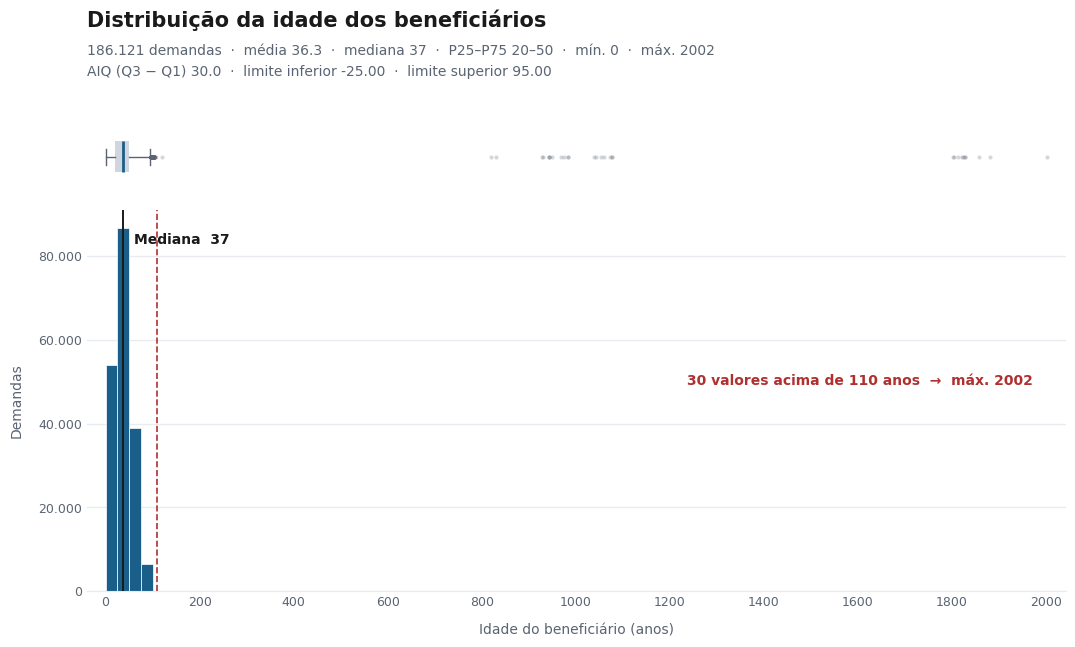

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

AZUL, CINZA = '#1A5F8A', '#D1D6DE'
INK, INK_SEC, GRID, SURFACE = '#1A1A1A', '#5A6472', '#E8EBEF', '#FFFFFF'
VERMELHO = '#B03030'

s = resultado['IDADE_BENEFICIARIO'].dropna()

LIMITE_PLAUSIVEL = 110
n_extremos = (s > LIMITE_PLAUSIVEL).sum()

fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, figsize=(11, 6.8), sharex=True,
    gridspec_kw={'height_ratios': [1, 5.5], 'hspace': 0.08}
)
fig.patch.set_facecolor(SURFACE)

ax_box.boxplot(
    s, vert=False, widths=0.45, patch_artist=True,
    medianprops=dict(color=AZUL, linewidth=2),
    boxprops=dict(facecolor=CINZA, edgecolor=CINZA, linewidth=0),
    whiskerprops=dict(color=INK_SEC, linewidth=1),
    capprops=dict(color=INK_SEC, linewidth=1),
    flierprops=dict(marker='o', markersize=3, markerfacecolor=INK_SEC,
                    markeredgecolor='none', alpha=0.25),
)
ax_box.set_facecolor(SURFACE)
ax_box.set_yticks([])
ax_box.tick_params(bottom=False, labelbottom=False)
for lado in ('top', 'right', 'left', 'bottom'):
    ax_box.spines[lado].set_visible(False)

# ESCALA DEFINIDA PELOS DADOS
lo, hi = float(s.min()), float(s.max())
ax_hist.hist(s, bins=np.linspace(lo, hi, 80), color=AZUL,
             edgecolor=SURFACE, linewidth=0.5)
ax_hist.set_facecolor(SURFACE)
ax_hist.set_xlim(lo - (hi-lo)*0.02, hi + (hi-lo)*0.02)
ax_hist.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12, integer=True))

q1, q3 = s.quantile(.25), s.quantile(.75)
aiq = q3 - q1
lim_inf, lim_sup = q1 - 1.5*aiq, q3 + 1.5*aiq
mediana, media = s.median(), s.mean()

ax_hist.axvline(mediana, color=INK, linewidth=1.4, zorder=5)
ax_hist.annotate(f'Mediana  {mediana:.0f}',
    xy=(mediana, ax_hist.get_ylim()[1]*0.92), xytext=(8, 0),
    textcoords='offset points', fontsize=10, color=INK,
    fontweight='semibold', va='center')

if n_extremos:
    ax_hist.axvline(LIMITE_PLAUSIVEL, color=VERMELHO, linewidth=1.2,
                    linestyle='--', zorder=5)
    ax_hist.annotate(
        f'{n_extremos} valores acima de {LIMITE_PLAUSIVEL} anos  →  máx. {hi:.0f}',
        xy=(hi, ax_hist.get_ylim()[1]*0.55), xytext=(-10, 0),
        textcoords='offset points', fontsize=10, color=VERMELHO,
        fontweight='semibold', va='center', ha='right')

ax_hist.set_xlabel('Idade do beneficiário (anos)', fontsize=10, color=INK_SEC, labelpad=10)
ax_hist.set_ylabel('Demandas', fontsize=10, color=INK_SEC, labelpad=10)
ax_hist.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.')))
ax_hist.grid(axis='y', color=GRID, linewidth=1)
ax_hist.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax_hist.spines[lado].set_visible(False)
ax_hist.spines['bottom'].set_color(GRID)
ax_hist.tick_params(colors=INK_SEC, labelsize=9, length=0)

subtitulo = (
    f"{len(s):,}".replace(',', '.') + " demandas  ·  "
    f"média {media:.1f}  ·  mediana {mediana:.0f}  ·  P25–P75 {q1:.0f}–{q3:.0f}  ·  "
    f"mín. {lo:.0f}  ·  máx. {hi:.0f}\n"
    f"AIQ (Q3 − Q1) {aiq:.1f}  ·  limite inferior {lim_inf:.2f}  ·  "
    f"limite superior {lim_sup:.2f}"
)
fig.text(0.09, 0.965, 'Distribuição da idade dos beneficiários',
         fontsize=15, fontweight='bold', color=INK, ha='left', va='top')
fig.text(0.09, 0.915, subtitulo, fontsize=10, color=INK_SEC,
         ha='left', va='top', linespacing=1.6)

fig.subplots_adjust(left=0.09, right=0.98, top=0.80, bottom=0.11)
plt.savefig('idade_diagnostico.png', dpi=300, facecolor=SURFACE)
plt.show()

In [ ]:
LIMITE_IDADE = 110
antes = len(resultado)

resultado = resultado[resultado['IDADE_BENEFICIARIO'] <= LIMITE_IDADE].copy()

registrar(f'Remoção de idade > {LIMITE_IDADE} anos', resultado,
          'valores incompatíveis com idade humana')

Remoção de idade > 110 anos                        186.091           -38


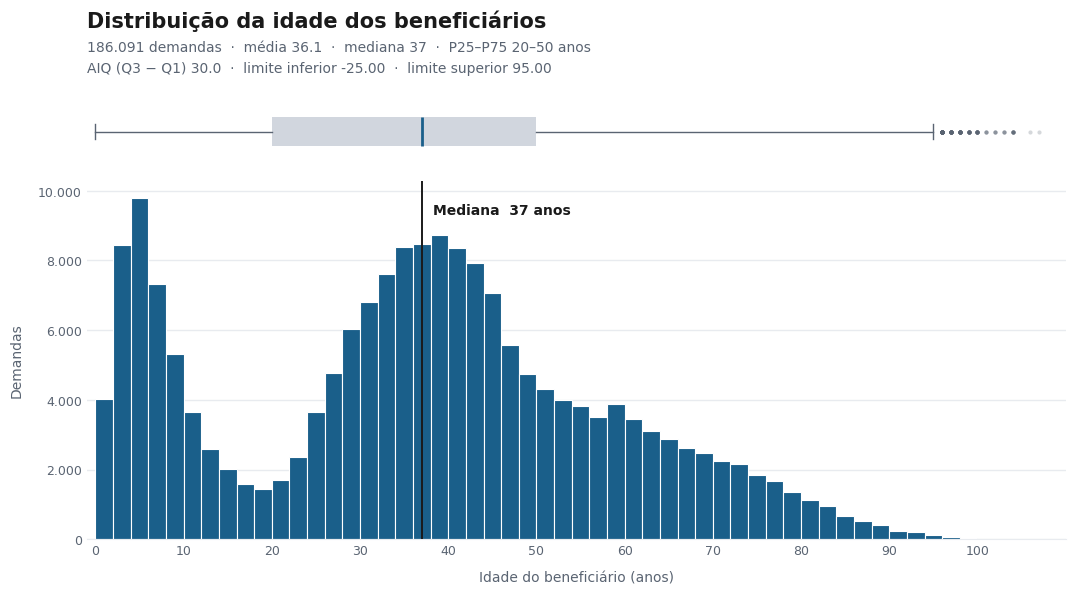

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

AZUL, CINZA = '#1A5F8A', '#D1D6DE'
INK, INK_SEC, GRID, SURFACE = '#1A1A1A', '#5A6472', '#E8EBEF', '#FFFFFF'

s = resultado['IDADE_BENEFICIARIO'].dropna()

fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, figsize=(11, 6.2), sharex=True,
    gridspec_kw={'height_ratios': [1, 5.5], 'hspace': 0.08}
)
fig.patch.set_facecolor(SURFACE)

# boxplot
ax_box.boxplot(
    s, vert=False, widths=0.45, patch_artist=True,
    medianprops=dict(color=AZUL, linewidth=2),
    boxprops=dict(facecolor=CINZA, edgecolor=CINZA, linewidth=0),
    whiskerprops=dict(color=INK_SEC, linewidth=1),
    capprops=dict(color=INK_SEC, linewidth=1),
    flierprops=dict(marker='o', markersize=3, markerfacecolor=INK_SEC,
                    markeredgecolor='none', alpha=0.25),
)
ax_box.set_facecolor(SURFACE)
ax_box.set_yticks([])
ax_box.tick_params(bottom=False, labelbottom=False)
for lado in ('top', 'right', 'left', 'bottom'):
    ax_box.spines[lado].set_visible(False)

# histograma
ax_hist.hist(s, bins=range(0, 110, 2), color=AZUL, edgecolor=SURFACE, linewidth=0.8)
ax_hist.set_facecolor(SURFACE)

q1, q3   = s.quantile(.25), s.quantile(.75)
aiq      = q3 - q1
lim_inf  = q1 - 1.5 * aiq
lim_sup  = q3 + 1.5 * aiq
mediana, media = s.median(), s.mean()

ax_hist.axvline(mediana, color=INK, linewidth=1.4, zorder=5)
ax_hist.annotate(
    f'Mediana  {mediana:.0f} anos',
    xy=(mediana, ax_hist.get_ylim()[1] * 0.92),
    xytext=(8, 0), textcoords='offset points',
    fontsize=10, color=INK, fontweight='semibold', va='center'
)

ax_hist.set_xlabel('Idade do beneficiário (anos)', fontsize=10, color=INK_SEC, labelpad=10)
ax_hist.set_ylabel('Demandas', fontsize=10, color=INK_SEC, labelpad=10)
ax_hist.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.'))
)
ax_hist.set_xlim(-1, 110)
ax_hist.set_xticks(range(0, 110, 10))
ax_hist.grid(axis='y', color=GRID, linewidth=1)
ax_hist.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax_hist.spines[lado].set_visible(False)
ax_hist.spines['bottom'].set_color(GRID)
ax_hist.tick_params(colors=INK_SEC, labelsize=9, length=0)

# títulos
subtitulo = (
    f"{len(s):,}".replace(',', '.') + " demandas  ·  "
    f"média {media:.1f}  ·  mediana {mediana:.0f}  ·  P25–P75 {q1:.0f}–{q3:.0f} anos\n"
    f"AIQ (Q3 − Q1) {aiq:.1f}  ·  "
    f"limite inferior {lim_inf:.2f}  ·  limite superior {lim_sup:.2f}"
)

fig.text(0.09, 0.965, 'Distribuição da idade dos beneficiários',
         fontsize=15, fontweight='bold', color=INK, ha='left', va='top')
fig.text(0.09, 0.915, subtitulo,
         fontsize=10, color=INK_SEC, ha='left', va='top', linespacing=1.6)


fig.subplots_adjust(left=0.09, right=0.98, top=0.82, bottom=0.11)
plt.savefig('idade_beneficiario.png', dpi=300, facecolor=SURFACE)
plt.show()

### 9.3 Remoção e rotulagem de ausentes

Conforme o critério da seção 9.1.

In [ ]:
COLS_REMOVER = ['IDADE_BENEFICIARIO', 'SEXO',
                'ESTADO_DO_BENEFICIARIO', 'MUNICIPIO_DO_BENEFICIARIO',
                'NATUREZA_DA_NIP']

resultado = resultado.dropna(subset=COLS_REMOVER)
registrar('Remoção de ausentes não informativos', resultado,
          f'colunas: {", ".join(COLS_REMOVER)}')

Remoção de ausentes não informativos               183.796        -2.295


In [ ]:
# Rotulagem — apenas colunas de texto. MUNIC_CONSUMIDOR_ATEND é numérica (código IBGE)
# e não recebe rótulo textual, sob pena de tornar a coluna de tipo misto.
COLS_NAO_INFORMADO = [
    'TIPOS_DE_COBER_CONTRATADAS',
    'TIPO_DE_PLANO_CONTRATADO',
    'UF_ONDE_CONSUMIDOR',
]
resultado[COLS_NAO_INFORMADO] = resultado[COLS_NAO_INFORMADO].fillna('Não informado')

print(resultado[COLS_NAO_INFORMADO].isnull().sum())

TIPOS_DE_COBER_CONTRATADAS    0
TIPO_DE_PLANO_CONTRATADO      0
UF_ONDE_CONSUMIDOR            0
dtype: int64


In [ ]:
# Uniformização dos rótulos de ausência já existentes na origem
resultado['EPOCA_DE_ADESAO_AO_PLANO'] = (
    resultado['EPOCA_DE_ADESAO_AO_PLANO']
      .replace('-', 'Não informado')
      .replace('NÃO INFORMADO', 'Não informado')
)
print(resultado['EPOCA_DE_ADESAO_AO_PLANO'].value_counts(dropna=False))

EPOCA_DE_ADESAO_AO_PLANO
POSTERIOR A 1999    174265
ANTERIOR A 1999       5785
Não informado         3746
Name: count, dtype: int64


In [ ]:
nulos = resultado.isnull().sum()
nulos_pct = (nulos / len(resultado)) * 100

resumo = pd.DataFrame({
    'TIPO': resultado.dtypes,
    'NULOS': nulos,
    'PERCENTUAL (%)': nulos_pct.round(2)
})
resumo = resumo[resumo['NULOS'] > 0].sort_values('NULOS', ascending=False)
print(resumo)

                           TIPO   NULOS  PERCENTUAL (%)
classe                  float64  115237           62.70
RESPOSTA_BENEFICIARIO    object  115237           62.70
MUNIC_CONSUMIDOR_ATEND  float64   56237           30.60
CLASSIFICACAO_DA_NIP     object    2380            1.29


### 9.4 Faixa etária

A idade é convertida nas **dez faixas etárias da RN nº 63/2003 da ANS**, que estruturam a
precificação por idade no setor de saúde suplementar.


> As faixas da RN 63 destinam-se originalmente ao reajuste por mudança de idade.
> Fiz uma **adaptação** para segmentação demográfica, não uma aplicação da norma.

In [ ]:
LIMITES = [-1, 18, 23, 28, 33, 38, 43, 48, 53, 58, np.inf]
ROTULOS = ['0 A 18 ANOS', '19 A 23 ANOS', '24 A 28 ANOS', '29 A 33 ANOS',
           '34 A 38 ANOS', '39 A 43 ANOS', '44 A 48 ANOS', '49 A 53 ANOS',
           '54 A 58 ANOS', '59 ANOS OU MAIS']

resultado['FAIXA_ETARIA'] = pd.cut(
    resultado['IDADE_BENEFICIARIO'],
    bins=LIMITES, labels=ROTULOS, right=True
)

print(resultado['FAIXA_ETARIA'].value_counts().sort_index())

FAIXA_ETARIA
0 A 18 ANOS        44999
19 A 23 ANOS        4708
24 A 28 ANOS       11126
29 A 33 ANOS       17281
34 A 38 ANOS       20856
39 A 43 ANOS       20440
44 A 48 ANOS       14841
49 A 53 ANOS       10487
54 A 58 ANOS        8919
59 ANOS OU MAIS    30139
Name: count, dtype: int64


In [ ]:
#del resultado['IDADE_BENEFICIARIO']    # informação preservada em FAIXA_ETARIA

### 9.5 Agrupamento de categorias pouco representativas

In [ ]:
contagem = resultado['FORMA_DE_CONTATO_COM_A_ANS'].value_counts(dropna=False)
pct = (contagem / len(resultado) * 100).round(2)

resumo = pd.DataFrame({'Contagem': contagem, 'Percentual (%)': pct})
print(resumo)

                            Contagem  Percentual (%)
FORMA_DE_CONTATO_COM_A_ANS                          
Telefone                      101789           55.38
Site                           80558           43.83
Pessoal                          920            0.50
Outros                           211            0.11
Carta/Ofício                     153            0.08
Nenhum                            62            0.03
Telefone - Ativo                  55            0.03
E-Mail                            10            0.01
Despacho                           9            0.00
Representação                      8            0.00
Chat                               6            0.00
Memorando                          4            0.00
Jornal / Revista                   4            0.00
Ouvidoria                          4            0.00
Fax                                3            0.00


In [ ]:
canais_principais = ['Telefone', 'Site']

resultado['FORMA_DE_CONTATO_COM_A_ANS'] = resultado['FORMA_DE_CONTATO_COM_A_ANS'].apply(
    lambda x: x if x in canais_principais else 'Outros'
)

### 9.6 Rótulo de mês

O mês é extraído da data de abertura da demanda e convertido em categoria **ordenada**, de
modo que qualquer contagem, agrupamento ou gráfico posterior respeite a ordem do calendário
em vez da ordem alfabética.


In [ ]:
MESES = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
         'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

resultado['MES_DE_REFERENCIA'] = resultado['ABERTURA_DA_DEMANDA'].dt.month.apply(
    lambda m: MESES[m - 1]
)
resultado['MES_DE_REFERENCIA'] = pd.Categorical(
    resultado['MES_DE_REFERENCIA'], categories=MESES, ordered=True
)
resultado = resultado.reset_index(drop=True)

print(resultado['MES_DE_REFERENCIA'].value_counts().sort_index())

MES_DE_REFERENCIA
Janeiro      16389
Fevereiro    15251
Março        19730
Abril        15914
Maio         13646
Junho        13315
Julho        14342
Agosto       15506
Setembro     15346
Outubro      16607
Novembro     15382
Dezembro     12368
Name: count, dtype: int64


In [ ]:
for c in resultado.select_dtypes('Int64').columns:
    resultado[c] = resultado[c].astype('int64')

resultado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183796 entries, 0 to 183795
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   NUMERO_DA_DEMANDA           183796 non-null  int64         
 1   ABERTURA_DA_DEMANDA         183796 non-null  datetime64[ns]
 2   ANO_DE_REFERENCIA           183796 non-null  int64         
 3   MES_DE_REFERENCIA           183796 non-null  category      
 4   FORMA_DE_CONTATO_COM_A_ANS  183796 non-null  object        
 5   REGISTRO_OPERADORA          183796 non-null  object        
 6   NOME_OPERADORA              183796 non-null  object        
 7   MODALIDADE_DA_OPERADORA     183796 non-null  object        
 8   TIPO_DE_PLANO_CONTRATADO    183796 non-null  object        
 9   EPOCA_DE_ADESAO_AO_PLANO    183796 non-null  object        
 10  TIPOS_DE_COBER_CONTRATADAS  183796 non-null  object        
 11  IDADE_BENEFICIARIO          183796 non-

---
## 10. Análise descritiva

Distribuição das variáveis categóricas da base tratada. Painéis com escala independente e
altura proporcional ao número de categorias; percentual e contagem indicados em cada barra.

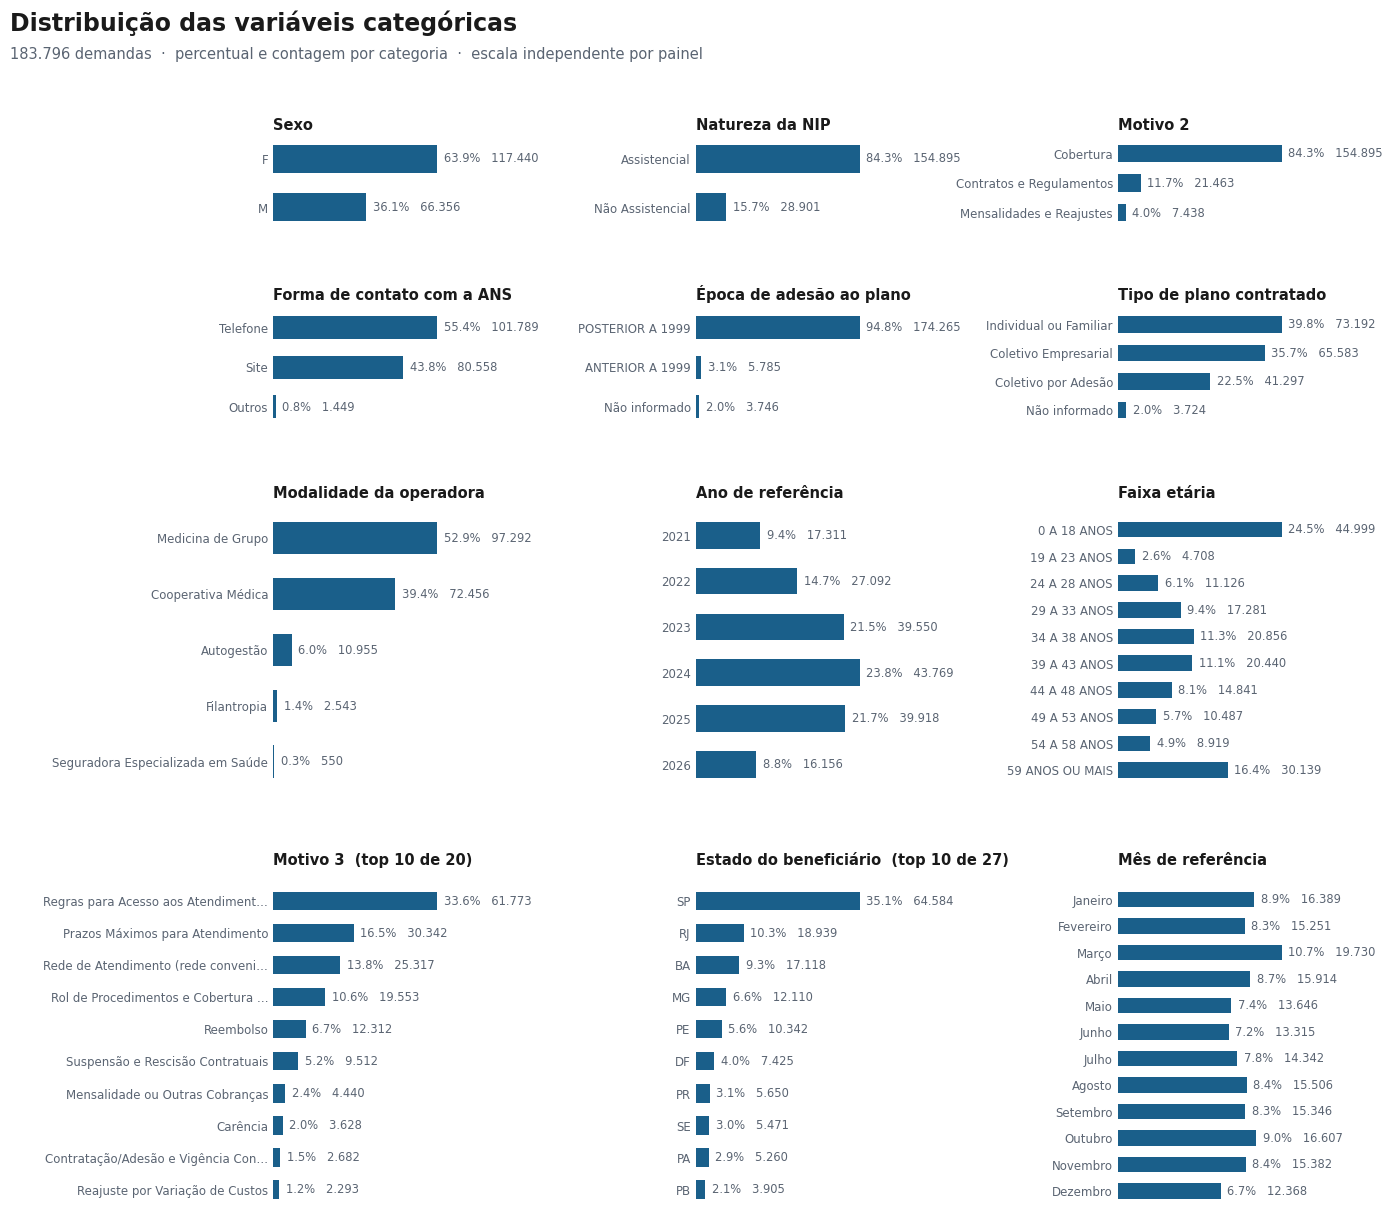

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- configuração
AZUL, INK, INK_SEC, SURFACE = '#1A5F8A', '#1A1A1A', '#5A6472', '#FFFFFF'

COLS = ['SEXO', 'NATUREZA_DA_NIP', 'Motivo 2', 'FORMA_DE_CONTATO_COM_A_ANS',
        'EPOCA_DE_ADESAO_AO_PLANO', 'TIPO_DE_PLANO_CONTRATADO',
        'MODALIDADE_DA_OPERADORA', 'ANO_DE_REFERENCIA', 'FAIXA_ETARIA',
        'Motivo 3', 'ESTADO_DO_BENEFICIARIO', 'MES_DE_REFERENCIA']

TOP_N      = 10        # limite de categorias por painel
NCOLS      = 3         # colunas da grade
MAX_ROTULO = 34        # trunca rótulos mais longos que isso

ORDENAR = {'FAIXA_ETARIA', 'ANO_DE_REFERENCIA'}   # ordem natural do índice
ORDENS = {
    'MES_DE_REFERENCIA': ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
                          'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'],
}

TITULOS = {
    'SEXO': 'Sexo',
    'NATUREZA_DA_NIP': 'Natureza da NIP',
    'FORMA_DE_CONTATO_COM_A_ANS': 'Forma de contato com a ANS',
    'MODALIDADE_DA_OPERADORA': 'Modalidade da operadora',
    'TIPO_DE_PLANO_CONTRATADO': 'Tipo de plano contratado',
    'EPOCA_DE_ADESAO_AO_PLANO': 'Época de adesão ao plano',
    'ESTADO_DO_BENEFICIARIO': 'Estado do beneficiário',
    'ANO_DE_REFERENCIA': 'Ano de referência',
    'MES_DE_REFERENCIA': 'Mês de referência',
    'FAIXA_ETARIA': 'Faixa etária',
}

def br(n):
    return f'{int(n):,}'.replace(',', '.')

# ------------------------------------------------------------------ contagens
dados = {}
for c in [c for c in COLS if c in resultado.columns]:
    vc = resultado[c].value_counts(dropna=False)
    n_cats = len(vc)

    if c in ORDENS:
        vc = vc.reindex(ORDENS[c]).dropna().astype(int)
        cortada = False
    elif c in ORDENAR:
        vc = vc.sort_index()
        cortada = False
    else:
        cortada = n_cats > TOP_N
        vc = vc.head(TOP_N)

    titulo = TITULOS.get(c, c.replace('_', ' ').capitalize())
    if cortada:
        titulo += f'  (top {TOP_N} de {n_cats})'
    dados[titulo] = vc

# ------------------------------------------- layout automático por nº de categorias
ordem   = sorted(dados, key=lambda k: len(dados[k]))
linhas  = [ordem[i:i + NCOLS] for i in range(0, len(ordem), NCOLS)]
alturas = [max(len(dados[v]) for v in ln) for ln in linhas]

ALT_CAT, ALT_TITULO = 0.30, 0.62
fig = plt.figure(figsize=(14, ALT_CAT * sum(alturas) + ALT_TITULO * len(linhas) + 1.3))
fig.patch.set_facecolor(SURFACE)
gs = fig.add_gridspec(len(linhas), NCOLS, height_ratios=alturas,
                      hspace=0.42, wspace=0.66,
                      left=0.20, right=0.985, top=0.88, bottom=0.02)

# --------------------------------------------------------------------- painéis
total = len(resultado)
for r, linha in enumerate(linhas):
    for c, var in enumerate(linha):
        ax = fig.add_subplot(gs[r, c])
        ax.set_facecolor(SURFACE)

        vc   = dados[var]
        cats = [(x if len(x) <= MAX_ROTULO else x[:MAX_ROTULO - 1] + '…')
                for x in map(str, vc.index)][::-1]
        cnts = list(vc.values)[::-1]
        pcts = [v / total * 100 for v in cnts]
        topo = max(pcts)

        ax.barh(cats, pcts, color=AZUL, height=0.58)
        ax.set_xlim(0, topo * 1.55)
        ax.set_xticks([])
        for lado in ('top', 'right', 'left', 'bottom'):
            ax.spines[lado].set_visible(False)
        ax.tick_params(colors=INK_SEC, labelsize=8.5, length=0)

        for y, (p, v) in enumerate(zip(pcts, cnts)):
            ax.text(p + topo * 0.04, y, f'{p:.1f}%   {br(v)}',
                    va='center', ha='left', fontsize=8.3, color=INK_SEC)

        ax.set_title(var, fontsize=10.5, fontweight='bold',
                     color=INK, loc='left', pad=8)

# --------------------------------------------------------------------- títulos
fig.text(0.012, 0.985, 'Distribuição das variáveis categóricas',
         fontsize=17, fontweight='bold', color=INK, ha='left', va='top')
fig.text(0.012, 0.955,
         f'{br(total)} demandas  ·  percentual e contagem por categoria  ·  '
         'escala independente por painel',
         fontsize=10.5, color=INK_SEC, ha='left', va='top')

plt.savefig('distribuicao_variaveis.png', dpi=300,
            facecolor=SURFACE, bbox_inches='tight')
plt.show()

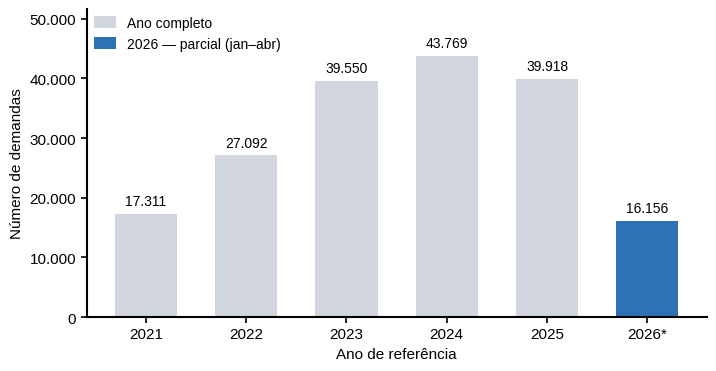

Figura X. Número de demandas por ano de referência
Fonte: Resultados originais da pesquisa
Nota: *2026 contempla apenas o período de jan a abr


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

PRETO, AZUL_CLARO, AZUL_ESCURO = '#000000', '#D1D6DE', '#2F72B3'

plt.rcParams.update({
    'font.family': ['Liberation Sans', 'DejaVu Sans'],
    'font.size': 11, 'text.color': PRETO, 'axes.labelcolor': PRETO,
    'xtick.color': PRETO, 'ytick.color': PRETO,
    'axes.grid': False, 'axes.facecolor': 'none', 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.5, 'axes.edgecolor': PRETO,
    'savefig.facecolor': 'white', 'savefig.bbox': 'tight', 'savefig.dpi': 300,
})

ABREV = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun',
         'jul', 'ago', 'set', 'out', 'nov', 'dez']

# ── dados ────────────────────────────────────────────────────────────────
contagem = resultado['ANO_DE_REFERENCIA'].value_counts().sort_index()

ano_parcial = contagem.index.max()
ultimo_mes = int(
    resultado.loc[resultado['ANO_DE_REFERENCIA'] == ano_parcial,
                  'ABERTURA_DA_DEMANDA'].dt.month.max()
)
periodo = f'jan–{ABREV[ultimo_mes - 1]}'

# ── gráfico ──────────────────────────────────────────────────────────────
rotulos = [f'{a}*' if a == ano_parcial else str(a) for a in contagem.index]
cores   = [AZUL_ESCURO if a == ano_parcial else AZUL_CLARO for a in contagem.index]

fig, ax = plt.subplots(figsize=(8, 4))

barras = ax.bar(rotulos, contagem.values, color=cores, width=0.62,

                linewidth=0.8)

for barra, valor in zip(barras, contagem.values):
    ax.text(barra.get_x() + barra.get_width() / 2,
            valor + contagem.max() * 0.022,
            f'{valor:,}'.replace(',', '.'),
            ha='center', va='bottom', fontsize=10, color=PRETO)

ax.set_xlabel('Ano de referência')
ax.set_ylabel('Número de demandas')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.')))
ax.set_ylim(0, contagem.max() * 1.18)
ax.tick_params(colors=PRETO, width=1.2, length=4)
for lado in ('left', 'bottom'):
    ax.spines[lado].set_linewidth(1.5)

ax.legend(handles=[
    Patch(facecolor=AZUL_CLARO, label='Ano completo'),
    Patch(facecolor=AZUL_ESCURO,  linewidth=0.3,
          label=f'{ano_parcial} — parcial ({periodo})'),
], loc='upper left', frameon=False, fontsize=10,
   handlelength=1.6, handleheight=1.0, borderpad=0, labelspacing=0.5)

plt.savefig('demandas_por_ano.png')
plt.show()

# ── legenda para colar no Word ───────────────────────────────────────────
print('Figura X. Número de demandas por ano de referência')
print('Fonte: Resultados originais da pesquisa')
print(f'Nota: *{ano_parcial} contempla apenas o período de '
      f'{periodo.replace("–", " a ")}')

In [ ]:
s = resultado['IDADE_BENEFICIARIO'].dropna()
print(f'Assimetria : {s.skew():.3f}')
print(f'Curtose    : {s.kurtosis():.3f}')
print(f'Quartis    : {s.quantile([.25, .5, .75]).round(1).to_dict()}')

Assimetria : 0.135
Curtose    : -0.639
Quartis    : {0.25: 20.0, 0.5: 37.0, 0.75: 50.0}


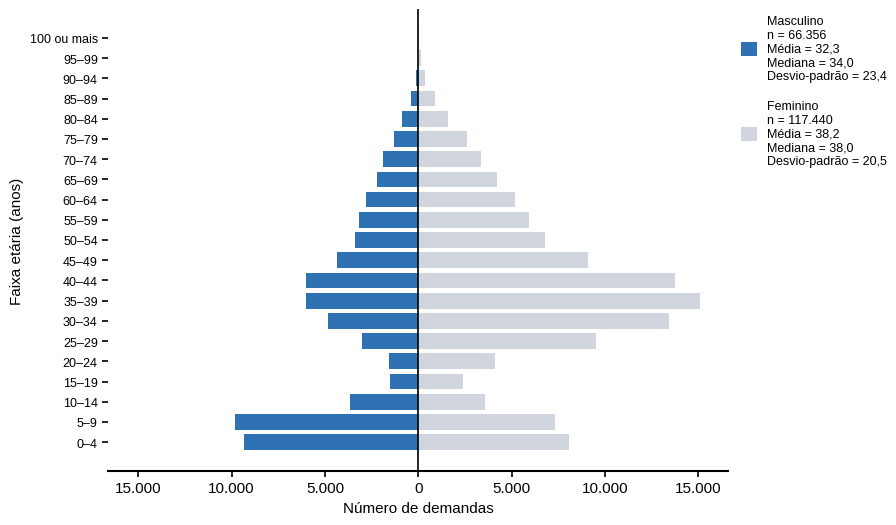

Figura X. Distribuição das demandas por faixa etária e sexo
Fonte: Resultados originais da pesquisa


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np

PRETO, AZUL_CLARO, AZUL_ESCURO = '#000000', '#D1D6DE', '#2F72B3'

plt.rcParams.update({
    'font.family': ['Liberation Sans', 'DejaVu Sans'],
    'font.size': 11, 'text.color': PRETO, 'axes.labelcolor': PRETO,
    'xtick.color': PRETO, 'ytick.color': PRETO,
    'axes.grid': False, 'axes.facecolor': 'none', 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.5, 'axes.edgecolor': PRETO,
    'savefig.facecolor': 'white', 'savefig.bbox': 'tight', 'savefig.dpi': 300,
})

def br(v, casas=0):
    """Formato brasileiro: ponto no milhar, vírgula no decimal."""
    return f'{v:,.{casas}f}'.replace(',', '~').replace('.', ',').replace('~', '.')

# ── faixas quinquenais ───────────────────────────────────────────────────
LIM = [-1] + list(range(5, 101, 5)) + [np.inf]
ROT = [f'{i}–{i+4}' for i in range(0, 100, 5)] + ['100 ou mais']

d = resultado.dropna(subset=['IDADE_BENEFICIARIO', 'SEXO']).copy()
d['FAIXA5'] = pd.cut(d['IDADE_BENEFICIARIO'], bins=LIM, labels=ROT, right=False)

tab = d.groupby(['FAIXA5', 'SEXO'], observed=False).size().unstack(fill_value=0)
tab = tab.loc[tab.sum(axis=1) > 0]          # remove faixas vazias no topo

esq, dir_ = tab['M'].values, tab['F'].values
faixas = list(tab.index.astype(str))

# ── gráfico ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(faixas))

ax.barh(y, -esq, color=AZUL_ESCURO, height=0.78, linewidth=0.3)
ax.barh(y,  dir_, color=AZUL_CLARO, height=0.78, linewidth=0.3)
ax.axvline(0, color=PRETO, linewidth=1.2)

lim = max(esq.max(), dir_.max()) * 1.10
ax.set_xlim(-lim, lim)
ax.set_yticks(y); ax.set_yticklabels(faixas, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: br(abs(v))))
ax.set_xlabel('Número de demandas')
ax.set_ylabel('Faixa etária (anos)')
ax.tick_params(colors=PRETO, width=1.2, length=4)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)

# ── estatísticas por sexo ────────────────────────────────────────────────
def bloco(rotulo, sexo):
    s = d.loc[d['SEXO'] == sexo, 'IDADE_BENEFICIARIO']
    return (f'{rotulo}\n'
            f'n = {br(len(s))}\n'
            f'Média = {br(s.mean(), 1)}\n'
            f'Mediana = {br(s.median(), 1)}\n'
            f'Desvio-padrão = {br(s.std(), 1)}')

ax.legend(handles=[
    Patch(facecolor=AZUL_ESCURO, label=bloco('Masculino', 'M')),
    Patch(facecolor=AZUL_CLARO, linewidth=0.5,
          label=bloco('Feminino', 'F')),
], loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False,
   fontsize=9, handlelength=1.3, handleheight=1.3,
   labelspacing=1.4, borderpad=0, alignment='left')

plt.savefig('piramide_etaria.png')
plt.show()

print('Figura X. Distribuição das demandas por faixa etária e sexo')
print('Fonte: Resultados originais da pesquisa')

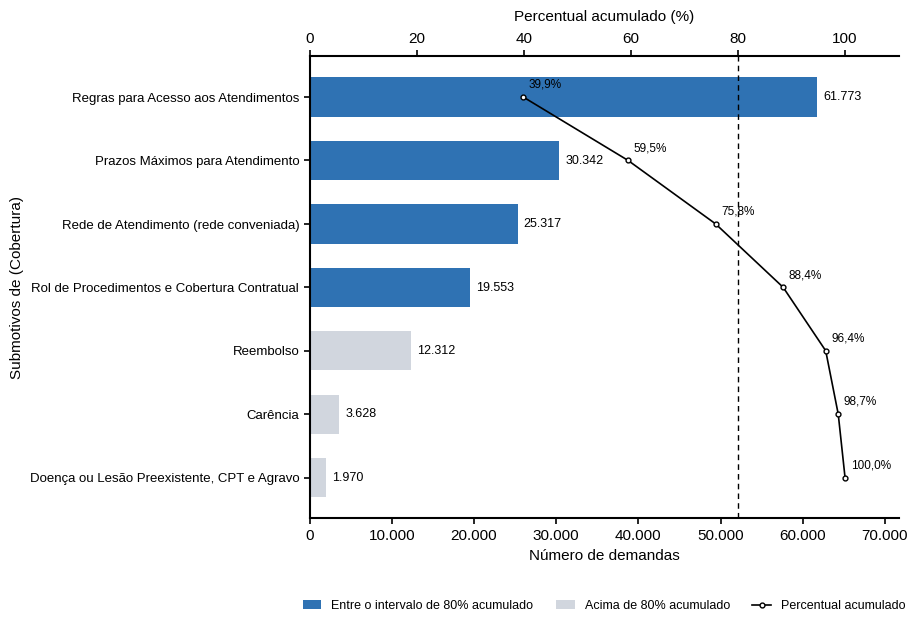

Figura X. Distribuição das demandas de Cobertura por motivo (análise de Pareto)
Fonte: Resultados originais da pesquisa
Nota: n = 154.895; 4 das 7 categorias concentram 88,4% das demandas

                                                 n     %  % acum.
Motivo 3                                                         
Regras para Acesso aos Atendimentos          61773  39.9     39.9
Prazos Máximos para Atendimento              30342  19.6     59.5
Rede de Atendimento (rede conveniada)        25317  16.3     75.8
Rol de Procedimentos e Cobertura Contratual  19553  12.6     88.4
Reembolso                                    12312   7.9     96.4
Carência                                      3628   2.3     98.7
Doença ou Lesão Preexistente, CPT e Agravo    1970   1.3    100.0


In [ ]:
from matplotlib.lines import Line2D
COL_G  = 'Motivo 2'      # coluna do agrupador
GRUPO  = 'Cobertura'     # recorte
COLUNA = 'Motivo 3'      # coluna detalhada
CORTE  = 80              # linha de referência de Pareto (%)

# ── estilo ──────────────────────────────────────────────────────────────
PRETO, AZUL_ESCURO, AZUL_CLARO = '#000000', '#2F72B3', '#D1D6DE'

def br(v, casas=0):
    """Formato numérico brasileiro: 61.773 / 39,4"""
    return f'{v:,.{casas}f}'.replace(',', '~').replace('.', ',').replace('~', '.')

# ── recorte e contagem ──────────────────────────────────────────────────
base = resultado.loc[resultado[COL_G].astype(str).str.strip() == GRUPO]

cont = (base[COLUNA].dropna().astype(str).str.strip()
        .value_counts().sort_values(ascending=False))
acum = cont.cumsum() / cont.sum() * 100
n_vital = int((acum < CORTE).sum()) + 1        # categorias até cruzar o corte

# ── figura ──────────────────────────────────────────────────────────────
altura = max(6.0, 0.42 * len(cont) + 1.2)
fig, ax = plt.subplots(figsize=(7.6, altura))
y = np.arange(len(cont))[::-1]                 # maior no topo

cores = [AZUL_ESCURO if i < n_vital else AZUL_CLARO for i in range(len(cont))]
ax.barh(y, cont.values, color=cores, height=0.62, linewidth=0.5)

for yi, v in zip(y, cont.values):
    ax.text(v + cont.max() * 0.012, yi, br(v),
            ha='left', va='center', fontsize=9, color=PRETO)

ax.set_yticks(y)
ax.set_yticklabels(cont.index, fontsize=9.5)
ax.set_xlim(0, cont.max() * 1.16)
ax.set_xlabel('Número de demandas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: br(v)))
ax.tick_params(colors=PRETO, width=1.2, length=4)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set_ylabel("Submotivos de (Cobertura)", color="black", fontsize=11)

# ── eixo superior: percentual acumulado ─────────────────────────────────
ax2 = ax.twiny()
ax2.plot(acum.values, y, color=PRETO, linewidth=1.2,
         marker='o', markersize=3.5, markerfacecolor='white',
          markeredgewidth=1.0, zorder=5)
ax2.axvline(CORTE, color=PRETO, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)

for yi, p in zip(y, acum.values):
    ax2.annotate(f'{br(p, 1)}%', (p, yi), textcoords='offset points',
                 xytext=(4, 9), ha='left', va='center',
                 fontsize=8.5, color=PRETO)

ax2.set_xlim(0, 110)
ax2.set_ylim(ax.get_ylim())
ax2.set_xticks(range(0, 101, 20))
ax2.set_xlabel('Percentual acumulado (%)', labelpad=8)
ax2.spines['top'].set_visible(True)
ax2.spines['top'].set_linewidth(1.5)
ax2.spines['top'].set_color(PRETO)
for lado in ('right', 'left', 'bottom'):
    ax2.spines[lado].set_visible(False)
ax2.tick_params(colors=PRETO, width=1.2, length=4)

ax.legend(handles=[
    Patch(facecolor=AZUL_ESCURO, linewidth=0.5,
          label=f'Entre o intervalo de {CORTE}% acumulado'),
    Patch(facecolor=AZUL_CLARO, linewidth=0.5,
          label=f'Acima de {CORTE}% acumulado'),
    Line2D([], [], color=PRETO, linewidth=1.2, marker='o', markersize=3.5,
           markerfacecolor='white', label='Percentual acumulado'),
], loc='upper center', bbox_to_anchor=(0.5, -0.06 - 0.62/altura), ncol=3,
   frameon=False, fontsize=9, handlelength=1.5, borderpad=0,
   columnspacing=1.8)

plt.savefig('pareto_motivo3_cobertura.png')
plt.show()

# ── legenda pronta para colar no Word ───────────────────────────────────
print(f'Figura X. Distribuição das demandas de {GRUPO} por motivo '
      f'(análise de Pareto)')
print('Fonte: Resultados originais da pesquisa')
print(f'Nota: n = {br(len(base))}; {n_vital} das {len(cont)} categorias '
      f'concentram {br(acum.iloc[n_vital-1], 1)}% das demandas')

# tabela de apoio para o texto
print()
print((cont.to_frame('n')
       .assign(**{'%': (cont / cont.sum() * 100).round(1),
                  '% acum.': acum.round(1)})).to_string())

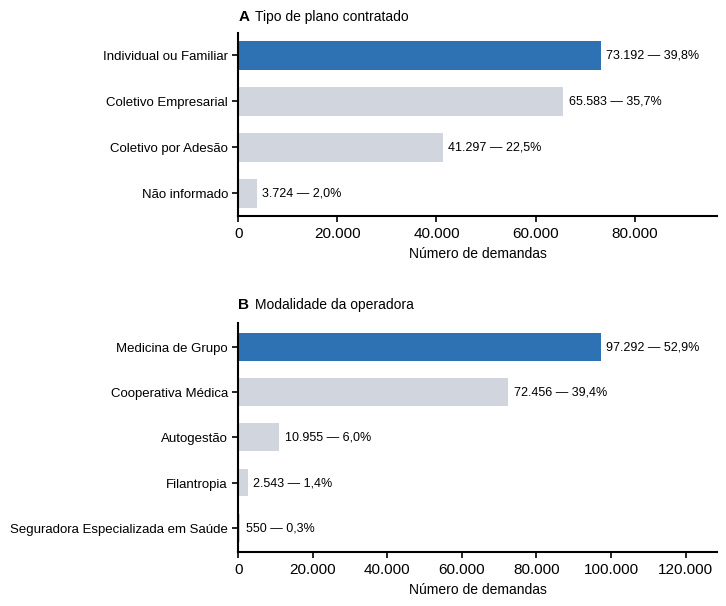

Figura X. Distribuição das demandas por tipo de plano contratado (A) e modalidade da operadora (B)
Fonte: Resultados originais da pesquisa
Nota: n = 183.796 demandas


In [ ]:
PAINEIS = [('TIPO_DE_PLANO_CONTRATADO', 'Tipo de plano contratado'),
           ('MODALIDADE_DA_OPERADORA',  'Modalidade da operadora')]

PRETO, AZUL_ESCURO, AZUL_CLARO = '#000000', '#2F72B3', '#D1D6DE'
plt.rcParams.update({
    'font.family': ['Liberation Sans', 'DejaVu Sans'],
    'font.size': 11, 'text.color': PRETO, 'axes.labelcolor': PRETO,
    'xtick.color': PRETO, 'ytick.color': PRETO,
    'axes.grid': False, 'axes.facecolor': 'none', 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.5, 'axes.edgecolor': PRETO,
    'savefig.facecolor': 'white', 'savefig.bbox': 'tight', 'savefig.dpi': 300,
})

def br(v, casas=0):
    """Formato brasileiro: 73.191 / 39,8"""
    return f'{v:,.{casas}f}'.replace(',', '~').replace('.', ',').replace('~', '.')

# altura de cada painel proporcional ao nº de categorias, para que as
# barras fiquem com a mesma espessura nos dois
alturas = [resultado[c].nunique() for c, _ in PAINEIS]

fig, eixos = plt.subplots(len(PAINEIS), 1, figsize=(7.4, 6.2),
                          gridspec_kw={'height_ratios': alturas})

for ax, (col, rotulo), letra in zip(eixos, PAINEIS, 'AB'):
    cont = resultado[col].value_counts().sort_values(ascending=False)
    pct  = cont / len(resultado) * 100
    y = np.arange(len(cont))[::-1]                 # maior no topo

    cores = [AZUL_ESCURO] + [AZUL_CLARO] * (len(cont) - 1)
    ax.barh(y, cont.values, color=cores, height=0.62,
             linewidth=0.5)

    for yi, v, p in zip(y, cont.values, pct.values):
        ax.text(v + cont.max() * 0.015, yi, f'{br(v)} — {br(p, 1)}%',
                ha='left', va='center', fontsize=9, color=PRETO)

    ax.set_yticks(y); ax.set_yticklabels(cont.index, fontsize=9.5)
    ax.set_xlim(0, cont.max() * 1.32)              # espaço para os rótulos
    ax.set_xlabel('Número de demandas', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: br(v)))
    ax.tick_params(colors=PRETO, width=1.2, length=4)
    for lado in ('left', 'bottom'):
        ax.spines[lado].set_linewidth(1.5)
    # identificação do painel + nome da variável, na mesma linha
    ax.text(0.0, 1.05, letra, transform=ax.transAxes, fontsize=11,
            fontweight='bold', color=PRETO, ha='left', va='bottom')
    ax.text(0.035, 1.05, rotulo, transform=ax.transAxes, fontsize=10,
            color=PRETO, ha='left', va='bottom')

plt.tight_layout(h_pad=2.4)
plt.savefig('freq_plano_modalidade.png')
plt.show()

print('Figura X. Distribuição das demandas por tipo de plano contratado (A) '
      'e modalidade da operadora (B)')
print('Fonte: Resultados originais da pesquisa')
print(f'Nota: n = {br(len(resultado))} demandas')

---
## 11. Base final

### Funil amostral

Caminho da base bruta até a amostra do estudo, com o efeito de cada critério.

In [ ]:
funil = pd.DataFrame(FUNIL)
funil['linhas'] = funil['linhas'].map(lambda v: f'{v:,}'.replace(',', '.'))
print(funil.to_string(index=False))

                               etapa    linhas   variação                                                                                            observação
          Base NIP bruta (2021–2026) 1.595.006                                                                                                                 
           Após merges (IGR + CADOP) 1.595.006         +0                                                                    left join: não deve alterar linhas
 Recorte: porte médio + ativa + méd.   186.129 -1.408.877                                                                                                      
         Remoção de idade > 110 anos   186.091        -38                                                                valores incompatíveis com idade humana
Remoção de ausentes não informativos   183.796     -2.295 colunas: IDADE_BENEFICIARIO, SEXO, ESTADO_DO_BENEFICIARIO, MUNICIPIO_DO_BENEFICIARIO, NATUREZA_DA_NIP


### Persistência

A base é gravada em **Excel**. A Etapa 2 (seleção de
variáveis e modelagem) parte deste arquivo, sem repetir o processamento.

In [ ]:
resultado.to_csv(SAIDA, index=False)

print(f'Base salva em: {SAIDA}')
print(f'Dimensões    : {resultado.shape[0]:,} linhas × {resultado.shape[1]} colunas'.replace(',', '.'))
print(f'Com resposta : {resultado["classe"].notna().sum():,} linhas'.replace(',', '.'))
print(f'Taxa base    : {resultado["classe"].mean()*100:.1f}% não resolvido')

Base salva em: /content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/base_analitica_tcc.csv
Dimensões    : 183.796 linhas × 31 colunas
Com resposta : 68.559 linhas
Taxa base    : 49.0% não resolvido


In [ ]:
resultado.head(3)

,NUMERO_DA_DEMANDA,ABERTURA_DA_DEMANDA,ANO_DE_REFERENCIA,MES_DE_REFERENCIA,FORMA_DE_CONTATO_COM_A_ANS,REGISTRO_OPERADORA,NOME_OPERADORA,MODALIDADE_DA_OPERADORA,TIPO_DE_PLANO_CONTRATADO,EPOCA_DE_ADESAO_AO_PLANO,TIPOS_DE_COBER_CONTRATADAS,IDADE_BENEFICIARIO,SEXO,ESTADO_DO_BENEFICIARIO,MUNICIPIO_DO_BENEFICIARIO,UF_ONDE_CONSUMIDOR,MUNIC_CONSUMIDOR_ATEND,CLASSIFICACAO_DA_NIP,NATUREZA_DA_NIP,RESPOSTA_BENEFICIARIO,IGR,QTD_RECLAMACOES,QTD_BENEFICIARIOS,IGR_LAG1,IGR_M3,REC_M3,BEN_M3,Motivo 2,Motivo 3,classe,FAIXA_ETARIA
0,5235508,2021-06-29,2021,Junho,Telefone,323926,UNIMED SÃO JOÃO DEL REI - COOPERATIVA DE TRABA...,Cooperativa Médica,Individual ou Familiar,POSTERIOR A 1999,Ambulatorial + Hospitalar s/ Obstetrícia (A) +...,3,M,MG,SAO JOAO DEL REI,MG,316250.0,INATIVA,Assistencial,NaN,23.68,5,21117,9.48,7.902015,1.666667,21091.666667,Cobertura,Regras para Acesso aos Atendimentos,NaN,0 A 18 ANOS
1,5376511,2021-10-12,2021,Outubro,Site,311961,UNIMED DE MANAUS COOP. DO TRABALHO MÉDICO LTDA,Cooperativa Médica,Individual ou Familiar,ANTERIOR A 1999,Ambulatorial + Hospitalar c/ Obstetrícia (A) +...,58,M,RJ,RIO DE JANEIRO,RJ,330455.0,NÚCLEO,Assistencial,Não resolvido,78.37,16,20417,63.43,98.192296,20.333333,20707.666667,Cobertura,Reembolso,1.0,54 A 58 ANOS
2,5215153,2021-06-11,2021,Junho,Telefone,367397,UNIMED CAMPINA GRANDE - COOPERATIVA DE TRABALH...,Cooperativa Médica,Coletivo por Adesão,POSTERIOR A 1999,Ambulatorial + Hospitalar c/ Obstetrícia (A) +...,45,F,PB,JOAO PESSOA,Não informado,NaN,INATIVA,Não Assistencial,NaN,28.89,12,41543,16.96,16.125521,6.666667,41342.333333,Contratos e Regulamentos,Suspensão e Rescisão Contratuais,NaN,44 A 48 ANOS


---
## Coordenadas municipais

Carga das sedes municipais oficiais do IBGE, via pacote `geobr` (IPEA), para uso como dimensão
geográfica no painel de Power BI.

Utiliza-se a **sede municipal**, não o centroide do polígono: a sede é onde a população se
concentra, enquanto o centro geométrico do território pode recair em área desabitada.

> PEREIRA, R. H. M.; GONÇALVES, C. N. et al. **geobr: Loading Shapefiles of Official Spatial
> Data Sets of Brazil**. Instituto de Pesquisa Econômica Aplicada, 2019.

In [ ]:
!pip install geobr -q
import unicodedata
import geobr

capitais = geobr.read_capitals()

capitais['LONGITUDE'] = capitais.geometry.x
capitais['LATITUDE']  = capitais.geometry.y

capitais = capitais.drop(columns='geometry')
print(capitais.shape)
capitais.head()



def normalizar(s: pd.Series) -> pd.Series:
    return (
        s.astype('string')
         .str.normalize('NFKD')
         .str.encode('ascii', 'ignore').str.decode('ascii')
         .str.upper()
         .str.strip()
         .str.replace(r'\s+', ' ', regex=True)
    )

capitais['name_muni'] = normalizar(capitais['name_muni'])
capitais['name_state']   = normalizar(capitais['name_state'])

capitais.head(10)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 713.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 77.4 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
municipalseats_2010.parquet: 100%|██████████| 179k/179k [00:00<00:00, 2.42MB/s]


(27, 10)


,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,year,LONGITUDE,LATITUDE
0,1100205.0,PORTO VELHO,11.0,RO,RONDONIA,1.0,Norte,2010.0,-63.831446,-8.768892
1,1200401.0,RIO BRANCO,12.0,AC,ACRE,1.0,Norte,2010.0,-67.810529,-9.978299
2,1302603.0,MANAUS,13.0,AM,AMAZONAS,1.0,Norte,2010.0,-60.023335,-3.134691
3,1400100.0,BOA VISTA,14.0,RR,RORAIMA,1.0,Norte,2010.0,-60.670533,2.816682
4,1501402.0,BELEM,15.0,PA,PARA,1.0,Norte,2010.0,-48.487826,-1.459845
5,1600303.0,MACAPA,16.0,AP,AMAPA,1.0,Norte,2010.0,-51.057405,0.038951
6,1721000.0,PALMAS,17.0,TO,TOCANTINS,1.0,Norte,2010.0,-48.351044,-10.163253
7,2111300.0,SAO LUIS,21.0,MA,MARANHAO,2.0,Nordeste,2010.0,-44.297919,-2.531886
8,2211001.0,TERESINA,22.0,PI,PIAUI,2.0,Nordeste,2010.0,-42.805270,-5.086342
9,2304400.0,FORTALEZA,23.0,CE,CEARA,2.0,Nordeste,2010.0,-38.589928,-3.723805


In [ ]:
capitais.to_csv('/content/drive/MyDrive/TCC_MBA_USP/Base Dados_TCC/dimensaoIBGE.csv', index=False)

In [ ]:
resultado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183796 entries, 0 to 183795
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   NUMERO_DA_DEMANDA           183796 non-null  int64         
 1   ABERTURA_DA_DEMANDA         183796 non-null  datetime64[ns]
 2   ANO_DE_REFERENCIA           183796 non-null  int64         
 3   MES_DE_REFERENCIA           183796 non-null  category      
 4   FORMA_DE_CONTATO_COM_A_ANS  183796 non-null  object        
 5   REGISTRO_OPERADORA          183796 non-null  object        
 6   NOME_OPERADORA              183796 non-null  object        
 7   MODALIDADE_DA_OPERADORA     183796 non-null  object        
 8   TIPO_DE_PLANO_CONTRATADO    183796 non-null  object        
 9   EPOCA_DE_ADESAO_AO_PLANO    183796 non-null  object        
 10  TIPOS_DE_COBER_CONTRATADAS  183796 non-null  object        
 11  IDADE_BENEFICIARIO          183796 non-

---
## Nota sobre `CD_MUNICIPIO_ATEND`

Resposta da ANS a pedido de esclarecimento sobre o campo:

> "Quanto ao item 1, indica-se que o solicitante se guie pelo Código contido em
> `MUNIC_CONSUMIDOR_ATEND` para tomar conhecimento da cidade onde o beneficiário informou ter
> realizado o atendimento. Esclareça-se que essa pergunta feita no cadastro de demandas é
> respondida por autodeclaração pelo próprio interlocutor da demanda NIP. Nem sempre vai se
> confundir com `MUNICIPIO_DO_BENEFICIARIO`, que foi concebido para trazer o domicílio do
> beneficiário. Sobre a inconsistência verificada em `CD_MUNICIPIO_ATEND`, também foi
> encaminhada à área técnica que avaliará a adoção de medidas. **Não considerar, portanto,
> esse campo, para compreensão do local do atendimento.**"

Motivo da exclusão de `CD_MUNICIPIO_ATEND` na seção 6.3.